# Computer Organisation & Architecture — 2310221L
### How CO1 and CO2 are used in Datapath Bench

This subject is not *applied to* the project — it is the thing the project simulates.

| | Outcome | Used for |
|---|---|---|
| **CO1** | Explicate the architecture and instruction set | The machine itself: registers, flags, 14 instructions |
| **CO2** | Develop assembly language programs | A two-pass assembler and six worked programs |

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle

PAPER  = "#FAF8F3"; BAND = "#F1EEE6"
NAVY   = "#1B2A34"; INK  = "#1C2320"
COPPER = "#B25E1C"; TEAL = "#0C5E50"
LINE   = "#C9C2B2"; MUTED = "#7C8781"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

def canvas(w=11, h=3.2, xlim=(0, 110), ylim=(0, 32)):
    fig, ax = plt.subplots(figsize=(w, h), dpi=150)
    fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    return fig, ax

def box(ax, x, y, w, h, title="", sub="", fc="white", ec=None, tc=None, fs=9, r=0.4):
    ec = ec or LINE; tc = tc or INK
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=%s" % r,
                 linewidth=1.3, edgecolor=ec, facecolor=fc, zorder=2))
    if title:
        ax.text(x + w/2, y + h/2 + (1.4 if sub else 0), title, ha="center", va="center",
                fontsize=fs, color=tc, weight="bold", zorder=3)
    if sub:
        ax.text(x + w/2, y + h/2 - 2.0, sub, ha="center", va="center",
                fontsize=fs-1.6, color=MUTED, zorder=3)

def arrow(ax, x1, y1, x2, y2, color=None, lw=1.4, style="-|>", ls="-"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                 mutation_scale=11, linewidth=lw, color=color or MUTED,
                 linestyle=ls, zorder=4, shrinkA=1, shrinkB=1))

def label(ax, x, y, t, color=None, fs=8.2, ha="center", weight="normal", style="normal"):
    ax.text(x, y, t, ha=ha, va="center", fontsize=fs,
            color=color or MUTED, weight=weight, style=style, zorder=5)

print('diagram helpers ready')

diagram helpers ready


---
## CO1 · Explicate the architecture and instruction set

We designed the machine: which registers exist, what the instructions are, how they are
encoded, and what connects everything together.

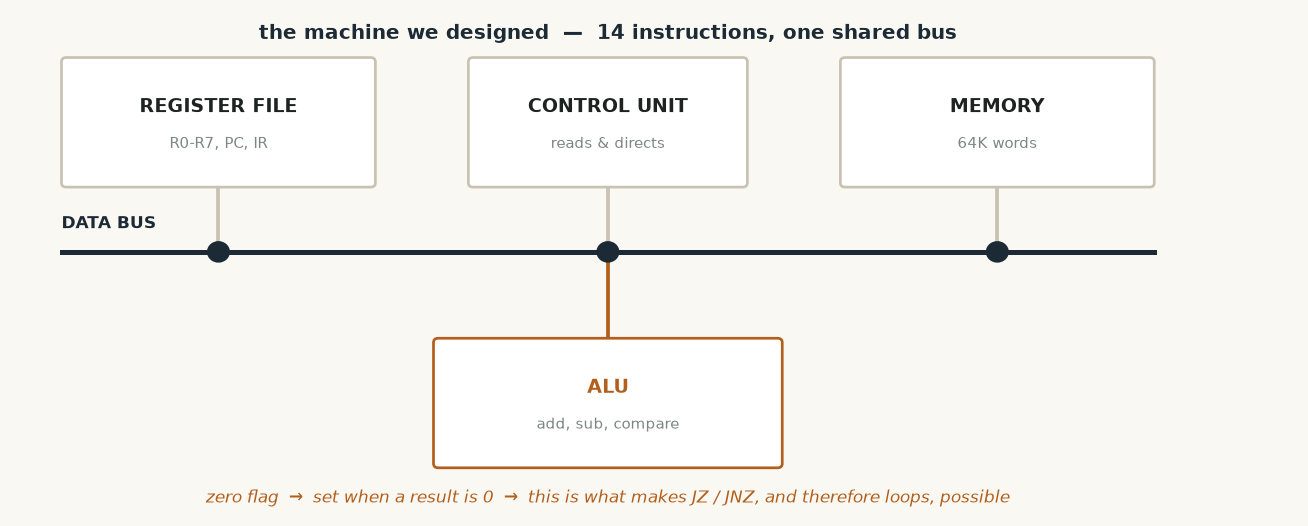

In [ ]:
fig, ax = canvas(h=4.3, ylim=(0, 46))
box(ax, 4,  30, 27, 12, "REGISTER FILE", "R0-R7, PC, IR", fc="white")
box(ax, 39, 30, 24, 12, "CONTROL UNIT", "reads & directs", fc="white")
box(ax, 71, 30, 27, 12, "MEMORY", "64K words", fc="white")
box(ax, 36, 4,  30, 12, "ALU", "add, sub, compare", fc="white", ec=COPPER, tc=COPPER)
ax.plot([4, 98], [24, 24], color=NAVY, lw=2.4, zorder=1)
label(ax, 4, 26.6, "DATA BUS", color=NAVY, fs=8, ha="left", weight="bold")
for x in (17.5, 51, 84.5):
    ax.plot([x, x], [24, 30], color=LINE, lw=1.8, zorder=1)
    ax.add_patch(Circle((x, 24), 0.9, color=NAVY, zorder=3))
ax.plot([51, 51], [16, 24], color=COPPER, lw=1.8, zorder=1)
label(ax, 51, 44.2, "the machine we designed  \u2014  14 instructions, one shared bus",
      color=NAVY, fs=9.5, weight="bold")
label(ax, 51, 1.2, "zero flag  \u2192  set when a result is 0  \u2192  this is what makes JZ / JNZ, and therefore loops, possible",
      color=COPPER, fs=8.2, style="italic")
plt.show()

| Element | What we designed |
|---|---|
| Registers | R0–R7 general purpose, plus PC, IR, SP, MAR, MDR |
| Instructions | 14 — LOAD, LOADM, STORE, MOV, ADD, SUB, CMP, INC, DEC, JMP, JZ, JNZ, OUT, HLT |
| Addressing | immediate, register-to-register, direct memory |
| Flag | zero flag, set whenever a result or comparison is 0 |
| Cycle | fetch → decode → execute → writeback, steppable one stage at a time |

Without a flag a processor can calculate but never **decide**. The zero flag is what
makes `JZ` and `JNZ` work, and therefore what makes loops possible at all.

```cpp
// one call to step() advances exactly one micro-stage
case STAGE_FETCH:      // PC drives the address, instruction loads into IR
case STAGE_DECODE:     // ask the instruction for its control signals
case STAGE_EXECUTE:    // the instruction does its work
case STAGE_WRITEBACK:  // PC advances, unless a branch already moved it
```

---
## CO2 · Develop assembly language programs

A two-pass assembler turns readable text into runnable instructions.

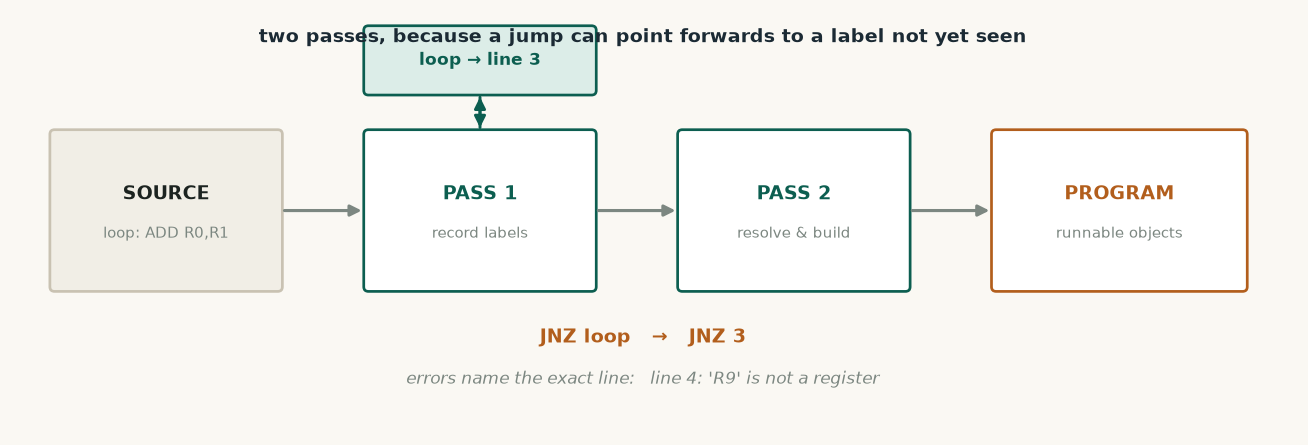

In [ ]:
fig, ax = canvas(h=3.6, ylim=(0, 36))
box(ax, 3,  12, 20, 14, "SOURCE", "loop: ADD R0,R1", fc=BAND)
box(ax, 30, 12, 20, 14, "PASS 1", "record labels", fc="white", ec=TEAL, tc=TEAL)
box(ax, 30, 29, 20, 6,  "", "", fc="#DCEDE8", ec=TEAL)
label(ax, 40, 32, "loop \u2192 line 3", color=TEAL, fs=8.2, weight="bold")
box(ax, 57, 12, 20, 14, "PASS 2", "resolve & build", fc="white", ec=TEAL, tc=TEAL)
box(ax, 84, 12, 22, 14, "PROGRAM", "runnable objects", fc="white", ec=COPPER, tc=COPPER)
arrow(ax, 23, 19, 30, 19, MUTED, 1.5)
arrow(ax, 40, 26, 40, 29, TEAL, 1.4)
arrow(ax, 40, 29, 40, 26, TEAL, 1.4)
arrow(ax, 50, 19, 57, 19, MUTED, 1.5)
arrow(ax, 77, 19, 84, 19, MUTED, 1.5)
label(ax, 54, 34, "two passes, because a jump can point forwards to a label not yet seen",
      color=NAVY, fs=9, weight="bold")
label(ax, 54, 8, "JNZ loop   \u2192   JNZ 3", color=COPPER, fs=9, weight="bold")
label(ax, 54, 4.4, "errors name the exact line:   line 4: 'R9' is not a register", fs=8, style="italic")
plt.show()

Two passes are necessary because a jump can refer to a label appearing **later** in the
file. Pass one only records where each label is; pass two builds the instructions and
resolves the references.

```cpp
// pass one — record every label's address
if (colon != std::string::npos) {
    std::string label = trim(t.substr(0, colon));
    if (!label.empty()) symbols_.put(label, address);
}
```

**A program that runs on it** — sums 1 to 5 and prints 15:

```asm
        LOAD  R0, #0        ; running total
        LOAD  R1, #1        ; counter
        LOAD  R2, #6        ; stop when the counter reaches 6
loop:   ADD   R0, R1        ; total = total + counter
        INC   R1
        MOV   R3, R1
        CMP   R3, R2        ; reached six?
        JNZ   loop          ; not yet — go round again
        STORE R0, [0x40]
        OUT   R0            ; prints 15
        HLT
```

Six such programs ship with the project. `programs/` also holds `sum.asm`,
`multiply.asm` and `subroutine.asm`, all verified: 55, 91 from two different multiply
methods, and 10/42/42 for CALL and RET.

---
## Held back for later parts

This notebook covers **CO1 and CO2 only** — the deliberate scope of the first working
prototype. The remaining outcomes are planned work, listed here so the omission reads
as planning rather than a gap.

| Outcome | Topic | Where it will be used |
|---|---|---|
| CO3 | Computer arithmetic algorithms | Add-and-shift multiply with a printed trace; carry and overflow |
| CO4 | Control signals and pipelining | A timing chart of the 14 signals, and a pipeline that visibly stalls |

---
*Datapath Bench — an integrated SY B.Tech project.*
*Vivek Dhamale · Pranjal Bhandari · Sanika Patil · Mrudula Bongulwar.*
*Guide: Mrs. Jaya S. Mane, Assistant Professor, Software Engineering Department.*